# Tracking of several entities using Trackpy

# Importations

In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience

import pims
import trackpy as tp

import cv2

from tqdm import tqdm
import os
import shutil
import time 

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
mpl.rc('figure',  figsize=(10, 5))
mpl.rc('image', cmap='gray')
mpl.rc('text', usetex=True)

In [3]:
import sys
sys.path.append("/home/nfares/postdoc/experiments/tracking/")

import trackpy_parallel as tpp

# Auxiliary functions

# Inputs

In [4]:
# Where to find the data
path2vid = '/home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_px_65nm_500fps.mp4'

# Frame rate
fps = 500

# Pixel size (in m)
px = 65e-9

# Get the frames 

In [5]:
@pims.pipeline
def gray(image, channel=2):
    return image[:, :, channel]  # Take just one channel

frames = gray(pims.open(path2vid))

# PyAV-based reading

In [6]:
frames

(PyAVReaderTimed,) processed through proc_func. Original repr:
    <Frames>
    Format: QuickTime / MOV
    Source: /home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_px_65nm_500fps.mp4
    Duration: 49.438 seconds
    Frame rate: 63.979 fps
    Length: 3163 frames
    Frame Shape: (512, 512, 3)
    

# Compute the background

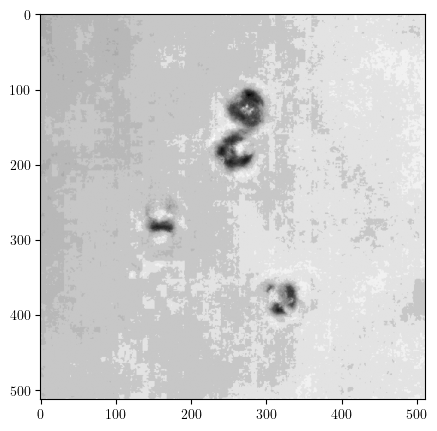

In [7]:
indexes = np.arange(0, 800, 10)
bg = np.median(frames[indexes], axis=0)
plt.figure()
plt.imshow(bg)
plt.show()

In [8]:
# Uncomment next cell if you want to load the background

In [9]:
# bg = cv2.imread('background.tiff')
# bg = gray(bg)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [10]:
# Uncomment next cell if you want to use a ''black'' background

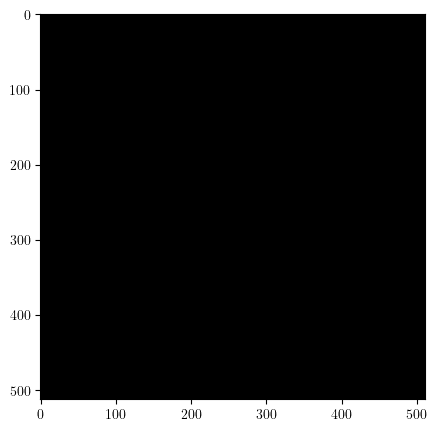

In [11]:
bg = np.zeros_like(frames[indexes[0]])

plt.figure()
plt.imshow(bg)
plt.show()

# One image: Track Particles

In [12]:
index = 0

In [13]:
im1 = frames[index]

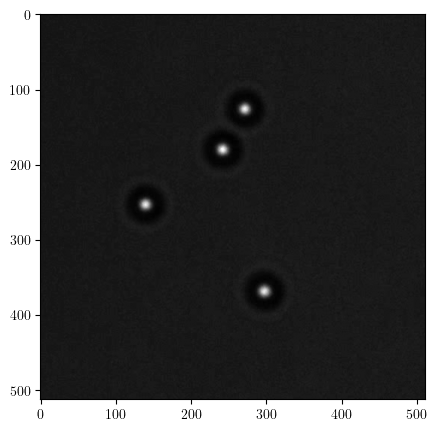

In [14]:
plt.imshow(im1);

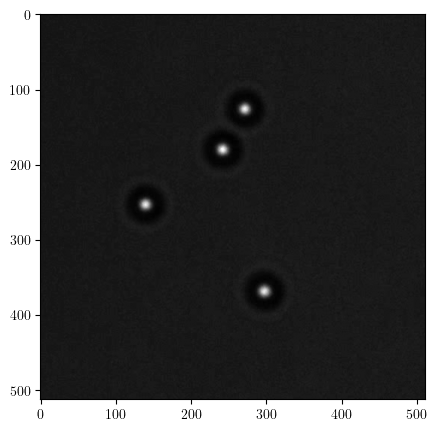

In [15]:
# im2 = (im1 - bg) 
im2 = im1
plt.imshow(im2)

In [16]:
# im2

In [17]:
f2 = tp.locate(im2, 15, invert=False, engine='python')

In [18]:
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,6.892000,110.460000,90.436356,4.245468,0.073035,2.170473,5521.0,0.044014,0
1,7.546816,294.464419,96.586028,4.539052,0.276113,2.893963,5849.0,0.037792,0
2,6.537594,412.048872,96.224282,3.916420,0.187707,3.255709,5950.0,0.036215,0
3,9.585366,211.135255,163.147186,4.862180,0.243008,3.617454,5739.0,0.039673,0
4,9.612420,434.396146,168.935112,4.401674,0.302847,3.255709,6011.0,0.035325,0


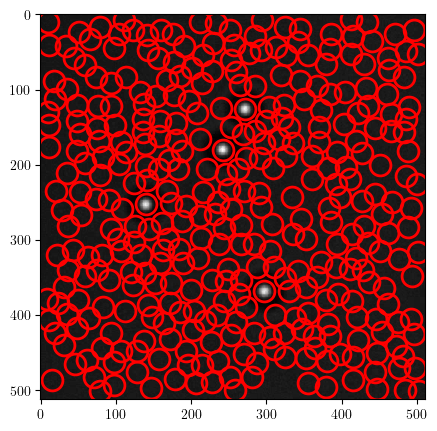

In [19]:
tp.annotate(f2, im2);

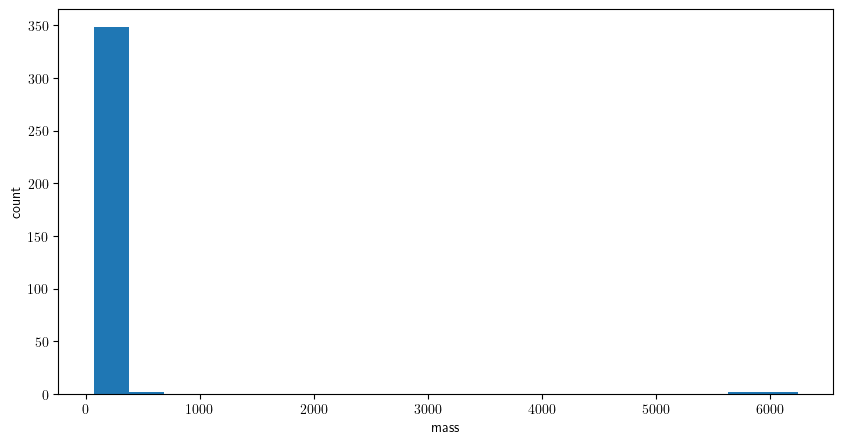

In [20]:
fig, ax = plt.subplots()
ax.hist(f2['mass'], bins=20)

# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

In [21]:
f2 = tp.locate(im2, 15, invert=False, minmass=3000, separation=15)
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
108,125.884160,271.228057,5992.674676,4.012138,0.020801,86.818901,20806.0,0.005075,0
150,179.807216,241.912439,6246.619963,4.010316,0.026211,92.245083,21630.0,0.004844,0
206,252.826485,139.707020,5889.577230,4.036601,0.020631,85.010174,20546.0,0.005153,0
306,368.108344,297.151202,5883.065813,4.129573,0.031408,78.498757,21192.0,0.004964,0


In [22]:
# f2

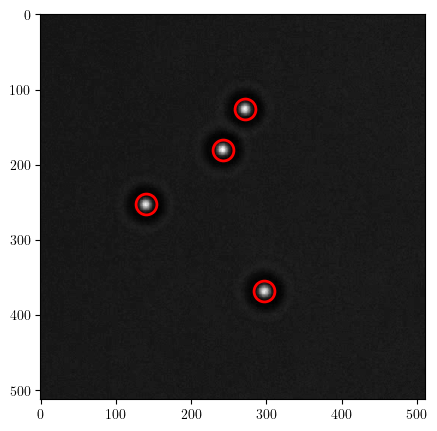

In [23]:
tp.annotate(f2, im2);

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

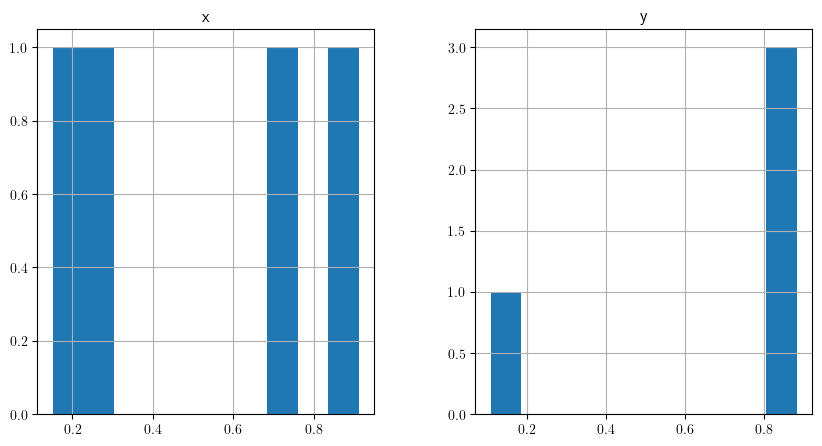

In [24]:
# Check sub-pixel accuracy
tp.subpx_bias(f2)
# Here I changed DataFrame.applymap to DataFrame.map in the source code, because of an update in pandas.
# Source code:
# ~/miniforge3/envs/ista/lib/python3.12/site-packages/trackpy/plots.py

# Using rings from bright-field microscopy

In [25]:
R = 21

In [26]:
%%time 
# Locate, without initial guess
fbf = tp.locate_brightfield_ring(frames[index], 2.0*R+1) # Use a slightly larger radius than expected

CPU times: user 84.4 ms, sys: 17.1 ms, total: 102 ms
Wall time: 2.13 s


In [27]:
fbf.head()

,y,x,r,frame
0,125.840086,271.386299,17.942440,0
1,179.968662,242.035911,18.822272,0
2,253.008143,139.709620,17.188255,0
3,367.967128,297.142321,16.171079,0


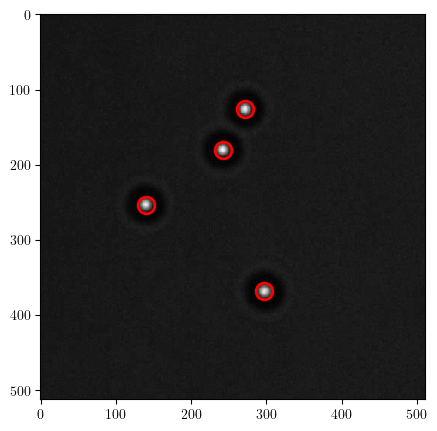

In [28]:
tp.annotate(fbf, frames[index], plot_style={'markersize': 12});

In [29]:
# Locate, with initial guess from no-ring locate function

# To be implemented as it is supposed to speed up the tracking, but not accuracy (according to trackpy doc). 

In [30]:
%%time 

fbf2 = tp.locate_brightfield_ring(frames[index], 2.0*R+1, previous_coords=f2)

CPU times: user 18.6 ms, sys: 6.88 ms, total: 25.5 ms
Wall time: 878 ms


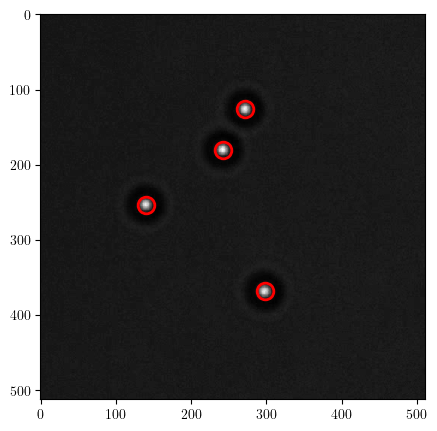

In [31]:
tp.annotate(fbf2, frames[index], plot_style={'markersize': 12});

In [32]:
# Let's see later, the accuracy seems to be dependent of the normal tracking and reduced

# Delete to clear your mind

In [33]:
del f2, fbf, fbf2

# Several Images: Tracking and Linking

## Inputs

In [34]:
start = 0
stop = len(frames)

In [35]:
R1 = 15 # radius for spot tracking
minmass = 3000
separation = 15
invert = False

In [36]:
n_workers = 20

In [37]:
path2vid

'/home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_px_65nm_500fps.mp4'

In [38]:
path2folder = '/home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/'

vidname = path2vid[len(path2folder):path2vid.find('.mp4')]
savename = path2folder + 'trajectories_' + vidname
print(savename)

/home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/trajectories_diffusion_px_65nm_500fps


## Perform Tracking

In [39]:
# Define args for input in the tracking function

args = (start, stop, R1, minmass, separation, invert)

In [40]:
# Parallel tracking 

f = tpp.process_video(video_path=path2vid, start=start, stop=stop, args=args, n_workers=n_workers)

0.83 GB will be loaded into shared memory.


100%|██████████| 3163/3163 [00:49<00:00, 64.02it/s]

Loaded 3163 frames, 0.83 GB into shared memory.


Wall time elapsed for the actual tracking = 0.0 min 22.373907566070557 s


In [41]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame


## Perform linking

In [42]:
# Inputs

search_range = 40
memory = 25

In [43]:
# Link trajectories

# tp.quiet()
t = tp.link(f, search_range=search_range, memory=memory)

Frame 3162: 4 trajectories present.


In [44]:
t.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,125.884160,271.228057,5992.674676,4.012138,0.020801,86.818901,20806.0,0.005075,0,0
1,179.807216,241.912439,6246.619963,4.010316,0.026211,92.245083,21630.0,0.004844,0,1
2,252.826485,139.707020,5889.577230,4.036601,0.020631,85.010174,20546.0,0.005153,0,2
3,368.108344,297.151202,5883.065813,4.129573,0.031408,78.498757,21192.0,0.004964,0,3
4,127.535367,272.774159,5936.368227,4.018970,0.027899,85.016481,20685.0,0.006717,1,0


In [45]:
# Filter too-short trajectories

t1 = tp.filter_stubs(t, threshold=50)

In [46]:
t1.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,125.884160,271.228057,5992.674676,4.012138,0.020801,86.818901,20806.0,0.005075,0,0
0,179.807216,241.912439,6246.619963,4.010316,0.026211,92.245083,21630.0,0.004844,0,1
0,252.826485,139.707020,5889.577230,4.036601,0.020631,85.010174,20546.0,0.005153,0,2
0,368.108344,297.151202,5883.065813,4.129573,0.031408,78.498757,21192.0,0.004964,0,3
1,127.535367,272.774159,5936.368227,4.018970,0.027899,85.016481,20685.0,0.006717,1,0


In [47]:
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Before: 4
After: 4


In [48]:
# Filter with conditions on tracked particles
# t2 = t1[((t1['size'] < 30))]
t2 = t1[((t1['ecc'] < 0.9))]

In [49]:
t2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,125.884160,271.228057,5992.674676,4.012138,0.020801,86.818901,20806.0,0.005075,0,0
0,179.807216,241.912439,6246.619963,4.010316,0.026211,92.245083,21630.0,0.004844,0,1
0,252.826485,139.707020,5889.577230,4.036601,0.020631,85.010174,20546.0,0.005153,0,2
0,368.108344,297.151202,5883.065813,4.129573,0.031408,78.498757,21192.0,0.004964,0,3
1,127.535367,272.774159,5936.368227,4.018970,0.027899,85.016481,20685.0,0.006717,1,0


In [50]:
# t2[t2['frame'] == start]

In [51]:
print(t2['particle'].nunique())

4


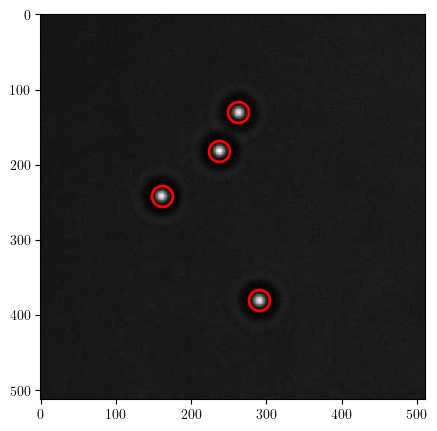

<Axes: >

In [52]:
i = 90
# plt.figure()
# plt.imshow(frames[start+i])
tp.annotate(t2[t2['frame'] == start+i], frames[start+i])

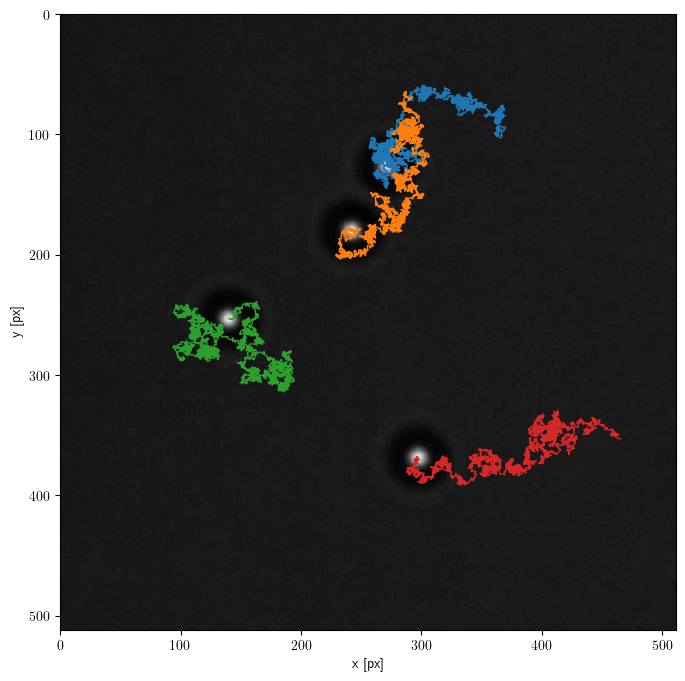

In [53]:
plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
tp.plot_traj(t2);

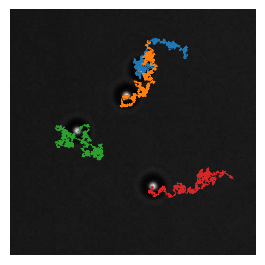

In [ ]:
p = t2['particle'].unique()
N = t2['particle'].nunique()

fig, ax = plt.subplots(figsize=(7/2.54, 7/2.54))
ax.imshow(frames[start])
for i in range(len(p)):
    x = t2[t2['particle'] == p[i]]['x']
    y = t2[t2['particle'] == p[i]]['y']
    ax.plot(x, y, linewidth=0.5)
    # plt.annotate(str(p[i]), (x.iloc[0], y.iloc[0]), c='white', size=15)
ax.axis('off')
plt.tight_layout()
plt.show()
# fig.savefig('example_tracking.pdf', dpi=600, bbox_inches='tight')

In [ ]:
# Check the displacement between consecutive frames for a given particle
p_id = 0
traj = t[t['particle'] == p_id].sort_values('frame')
traj['dx'] = traj['x'].diff()
traj['dy'] = traj['y'].diff()
traj['displacement'] = (traj['dx']**2 + traj['dy']**2)**0.5
print(traj['displacement'].max() / (px*1e6))

65.84829443424883


In [68]:
# # Compute drifts

# d = tp.compute_drift(t2)

# d.plot()
# plt.show()

## Checks With MSDs: Last Selection of Tracked Particles 

In [69]:
# Get trajectories

tm = t2.copy() #tp.subtract_drift(t2.copy(), d)

In [70]:
# plt.figure()
# plt.imshow(frames[start])
# tp.plot_traj(tm)
# plt.show()

In [71]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second

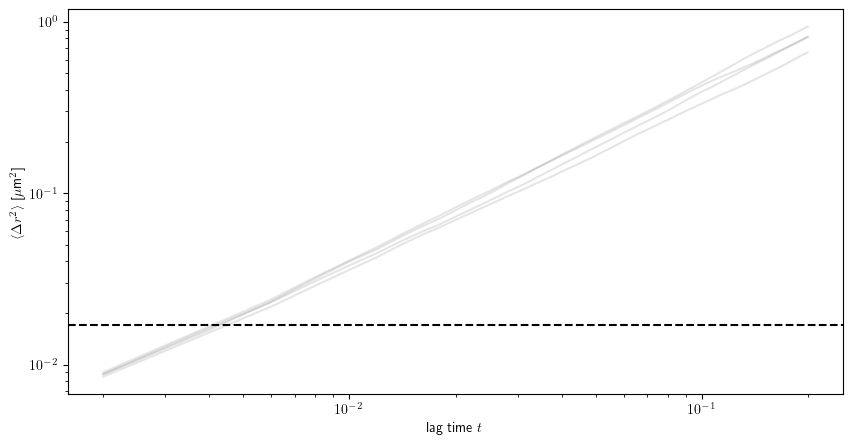

In [72]:
fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')

In [73]:
from scipy.optimize import curve_fit

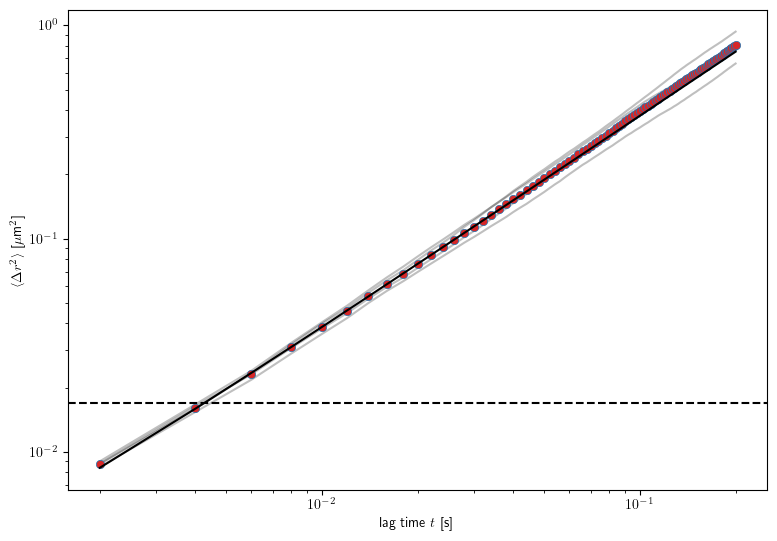

In [96]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second
em = tp.emsd(tm, px*1e6, fps)  # microns per pixel, frames per second

lag = em.index

f_diffusion = lambda t, D, d: 4*D*t+(2*d)**2

lagmin = 0
lagmax = 15
popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 0])

fig, ax = plt.subplots(1, 1, figsize=(20/2.54,14/2.54))
ax.plot(im.index, im, 'k-', alpha=0.25)  # black lines, semitransparent
ax.plot(em.index, em, 'o', mfc='tab:red', mew=0.5, mec='tab:blue')  
ax.plot(em.index, f_diffusion(em.index, *popt), ls='-', c='k')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$ [s]')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set(xlim=[None, 4e-2], ylim=[None, 2e-1])
plt.tight_layout()
plt.show()
fig.savefig('quick_MSD.pdf', transparent=True, dpi=600, bbox_inches='tight')

In [100]:
print(popt)

[0.94086373 0.01482699]


# Save Final Trajectories

In [91]:
tm['x'] = tm['x'] * px
tm['y'] = tm['y'] * px
tm.to_pickle(savename)

In [91]:
# tm = pd.read_pickle(savename)